# 🧪 Statistical Tests — Worksheet
**Name:** _______________________   **Date:** _______________________

---
**How this works:**
- Each task gives you a question and a starting line or two
- You write the logic, the test, and the visualisation
- 💡 hints tell you *what* to use — not *how*
- Every chart needs a proper title, xlabel, ylabel — your job

```
p ≤ 0.05 → Reject H₀    |    p > 0.05 → Keep H₀
```
---

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
np.random.seed(42)
print('Ready')

Ready


---
## 📦 Dataset — Build It

Create a DataFrame called `df` with **200 student records** using these specs:

| Column | Details |
|--------|---------|
| `gender` | Male / Female, random |
| `study_hours` | Normal(mean=4, std=1.2), clipped 0–10 |
| `sleep_hours` | Normal(mean=7, std=1.0), clipped 4–10 |
| `marks` | `study*6 + sleep*2 + noise(0,8)`, clipped 0–100 |
| `subject` | Maths 40%, Science 35%, Arts 25% |
| `passed` | 'Yes' if marks ≥ 50 else 'No' |
| `school` | School A / B / C / D — equal chance |

After creating marks, add a school boost: A:+5, B:0, C:−5, D:+10 (clip to 100).

💡 `np.random.choice` · `np.random.normal` · `.clip()` · `np.where` · `pd.DataFrame`

In [19]:
n = 200
# Write all your code here to build df

np.random.seed(42)  # for reproducibility
n = 200

# 1️⃣ Gender (Male / Female, random)
gender = np.random.choice(['Male', 'Female'], size=n)

# 2️⃣ Study hours (Normal, mean=4, std=1.2, clipped 0–10)
study_hours = np.clip(np.random.normal(4, 1.2, n), 0, 10)

# 3️⃣ Sleep hours (Normal, mean=7, std=1.0, clipped 4–10)
sleep_hours = np.clip(np.random.normal(7, 1.0, n), 4, 10)

# 4️⃣ Subject (Maths 40%, Science 35%, Arts 25%)
subject = np.random.choice(['Maths', 'Science', 'Arts'], size=n, p=[0.4, 0.35, 0.25])

# 5️⃣ Marks (study*6 + sleep*2 + noise(0,8), clipped 0–100)
noise = np.random.normal(0, 8, n)
marks = np.clip(study_hours*6 + sleep_hours*2 + noise, 0, 100)

# 6️⃣ School (A/B/C/D equal chance)
school = np.random.choice(['A', 'B', 'C', 'D'], size=n)

# 7️⃣ Apply school boost: A:+5, B:0, C:-5, D:+10
boost = {'A': 5, 'B': 0, 'C': -5, 'D': 10}
marks += [boost[s] for s in school]
marks = np.clip(marks, 0, 100)  # clip after boost

# 8️⃣ Passed (Yes if marks >=50 else No)
passed = ['Yes' if m >= 50 else 'No' for m in marks]

# 9️⃣ Build DataFrame
df = pd.DataFrame({
    'gender': gender,
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'subject': subject,
    'school': school,
    'marks': marks,
    'passed': passed
})






# Verify
print(df.shape)   # should be (200, 7)
df.head(3)

(200, 7)


,gender,study_hours,sleep_hours,subject,school,marks,passed
0,Male,4.104456,7.199060,Maths,B,36.338581,No
1,Female,3.641191,6.399783,Maths,D,57.998886,Yes
2,Male,4.110113,7.069802,Science,C,31.723551,No


---
## Task 1 — Explore the Data (Visualisation)

Before any test, look at your data. Create a **2×2 grid of subplots**:
- `[0,0]` Histogram of `marks`
- `[0,1]` Histogram of `study_hours`
- `[1,0]` Boxplot of `marks` by `gender`
- `[1,1]` Boxplot of `marks` by `school`

Label everything. Write one observation below each plot as a comment.

💡 `plt.subplots(2,2)` · `ax.hist()` · `df.boxplot(column, by, ax=)`

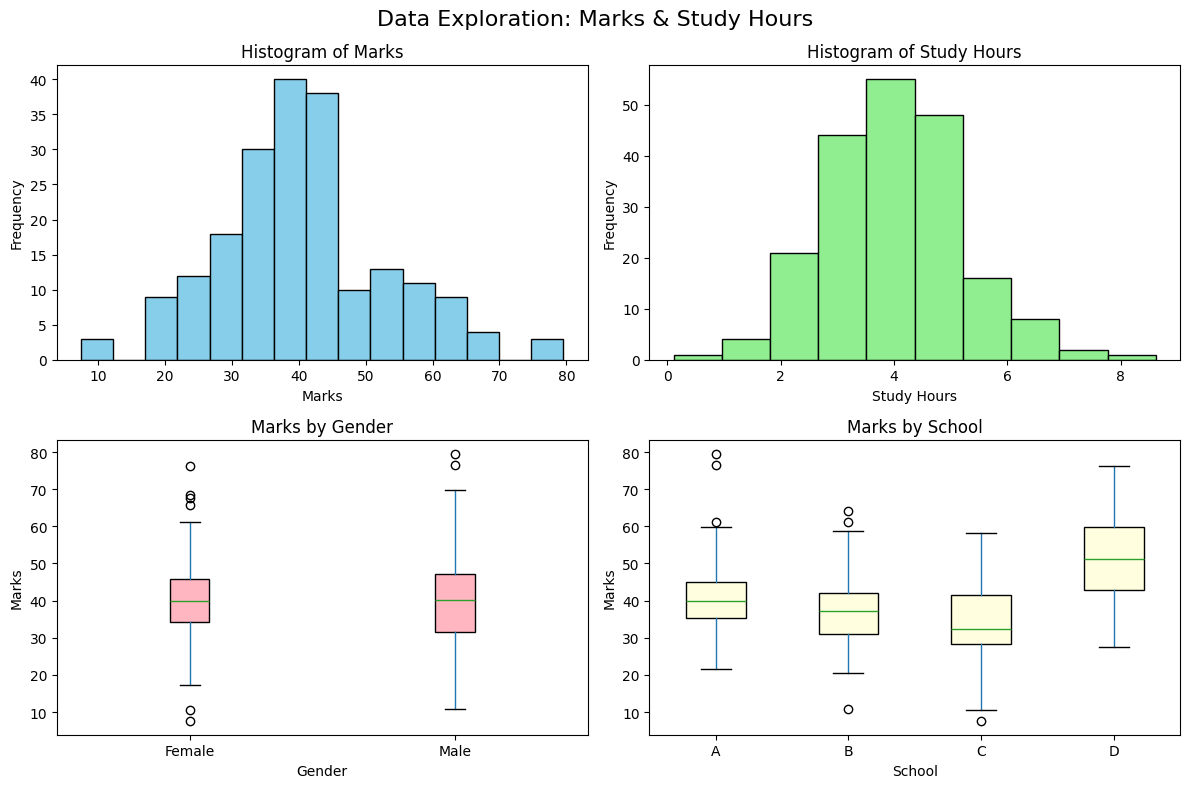

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Write your 4 subplots here

# [0,0] Histogram of marks
axes[0,0].hist(df['marks'], bins=15, color='skyblue', edgecolor='black')
axes[0,0].set_title('Histogram of Marks')
axes[0,0].set_xlabel('Marks')
axes[0,0].set_ylabel('Frequency')
# Observation: Most students score around the middle (35-50), few very low or very high.

# [0,1] Histogram of study_hours
axes[0,1].hist(df['study_hours'], bins=10, color='lightgreen', edgecolor='black')
axes[0,1].set_title('Histogram of Study Hours')
axes[0,1].set_xlabel('Study Hours')
axes[0,1].set_ylabel('Frequency')
# Observation: Study hours are roughly normally distributed around 4 hours/day.

# [1,0] Boxplot of marks by gender
df.boxplot(column='marks', by='gender', ax=axes[1,0], grid=False, patch_artist=True,
           boxprops=dict(facecolor='lightpink'))
axes[1,0].set_title('Marks by Gender')
axes[1,0].set_xlabel('Gender')
axes[1,0].set_ylabel('Marks')
# Observation: Median marks are similar between males and females; spread is slightly higher for males.

# [1,1] Boxplot of marks by school
df.boxplot(column='marks', by='school', ax=axes[1,1], grid=False, patch_artist=True,
           boxprops=dict(facecolor='lightyellow'))
axes[1,1].set_title('Marks by School')
axes[1,1].set_xlabel('School')
axes[1,1].set_ylabel('Marks')
# Observation: School D has the highest median (due to +10 boost), School C has the lowest (-5).

plt.suptitle('Data Exploration: Marks & Study Hours', fontsize=16)
plt.tight_layout()
plt.show()

# Observations:
# [0,0]: 
# [0,1]: 
# [1,0]: 
# [1,1]: 

---
## Task 2 — Normality Test

Test all three numeric columns (`marks`, `study_hours`, `sleep_hours`) for normality.

- Loop over the columns
- Run Shapiro-Wilk for each
- Print: column name, p-value, and verdict
- Draw Q-Q plots for all three in a 1×3 row

💡 `stats.shapiro()` · `stats.probplot(col, plot=ax)`

Shapiro-Wilk Normality Test Results:

marks        | p-value = 0.0084 | Verdict: Not Normal
study_hours  | p-value = 0.1014 | Verdict: Normal
sleep_hours  | p-value = 0.5952 | Verdict: Normal


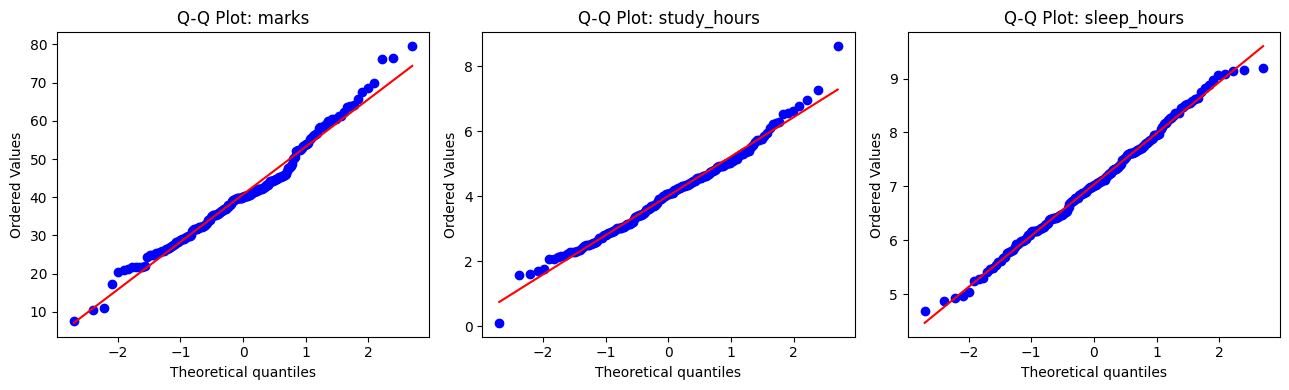

In [21]:
cols = ['marks', 'study_hours', 'sleep_hours']

# Loop + test + print
cols = ['marks', 'study_hours', 'sleep_hours']

print("Shapiro-Wilk Normality Test Results:\n")
for col in cols:
    stat, p = stats.shapiro(df[col])
    verdict = "Normal" if p > 0.05 else "Not Normal"
    print(f"{col:12} | p-value = {p:.4f} | Verdict: {verdict}")



# Q-Q plots — 1×3
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, col in enumerate(cols):
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q Plot: {col}")



plt.tight_layout()
plt.show()

# Which columns are safe for parametric tests?
# Answer: study_hours and sleep_hours, as they have p-values that are equal or abive the normal threshold

---
## Task 3 — t-test: Gender vs Marks

**Question:** Do Male and Female students score differently?

- H₀: Male and female marks have the same mean
- H₁: Means are different

Run the test, print results, write your if/else verdict, then draw a **violin plot** split by gender.

💡 `stats.ttest_ind()` · `sns.violinplot()`

T-statistic = -0.0825, p-value = 0.9343
Verdict: Fail to reject H₀ → No significant difference


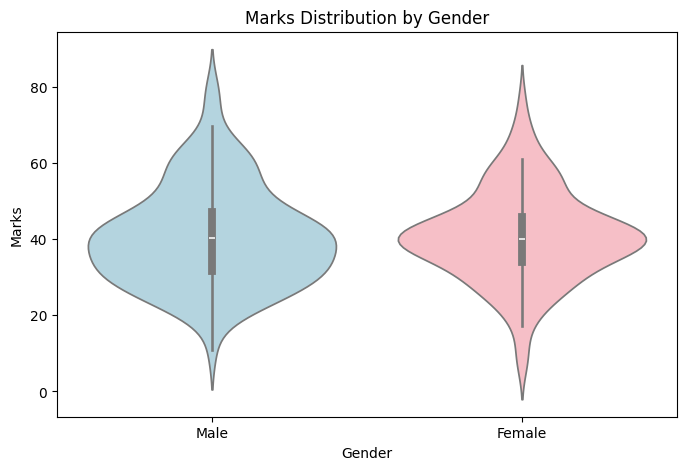

In [22]:
# Separate groups, run test, print, verdict, plot
# ---- Separate groups ----
male_marks = df[df['gender']=='Male']['marks']
female_marks = df[df['gender']=='Female']['marks']

# ---- Run independent t-test ----
t_stat, p_value = stats.ttest_ind(male_marks, female_marks)
print(f"T-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
# The t-statistic is a number that measures how big the difference between two group means is compared to the variability within the groups.
# Bigger t → bigger difference relative to spread
# Smaller t → means are closer together


# ---- Verdict ----
verdict = "Fail to reject H₀ → No significant difference" if p_value > 0.05 else "Reject H₀ → Significant difference"
print("Verdict:", verdict)

# ---- Plot violin plot ----
plt.figure(figsize=(8,5))
sns.violinplot(x='gender', y='marks', data=df, hue='gender', palette=['lightblue','lightpink'], dodge=False, legend=False)
plt.title("Marks Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Marks")
plt.show()







---
## Task 4 — ANOVA + Post-hoc: Schools vs Marks

**Question:** Do all 4 schools score the same?

- Run ANOVA first — if significant, run Tukey HSD to find which pairs differ
- Print ANOVA result + Tukey summary
- Draw a **bar chart with error bars** (mean ± std per school)

💡 `stats.f_oneway(*groups)` · `pairwise_tukeyhsd(endog, groups, alpha=0.05)` · `ax.bar(yerr=)`

ANOVA result: F-statistic = 21.5732, p-value = 0.0000
ANOVA is significant → run Tukey HSD post-hoc test

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  -3.8536  0.274  -9.3853  1.6781  False
     A      C  -7.2446 0.0043 -12.7456 -1.7435   True
     A      D   9.8244 0.0001   4.2278 15.4211   True
     B      C   -3.391 0.4202  -9.1254  2.3435  False
     B      D   13.678    0.0   7.8518 19.5043   True
     C      D   17.069    0.0  11.2719 22.8661   True
-----------------------------------------------------


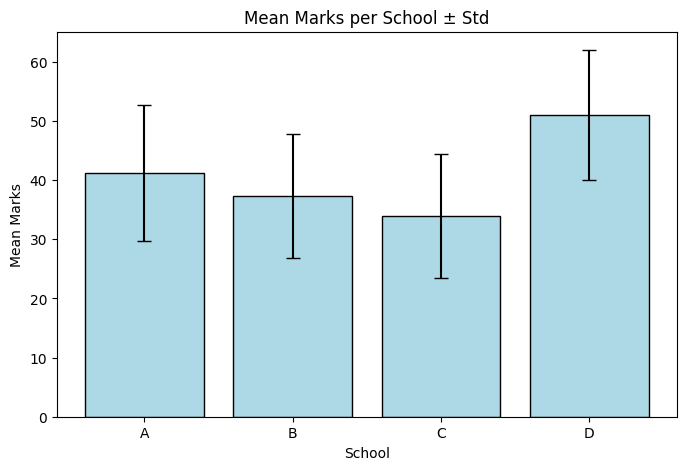

In [23]:
# Tukey HSD (Honestly Significant Difference) is a post-hoc test used after an ANOVA
# When you run ANOVA, it tells you:
# “At least one group mean is different”
# Problem: ANOVA doesn’t tell which groups differ.
# Solution: Tukey HSD compares all pairs of groups to find exactly which means are significantly different.

from statsmodels.stats.multicomp import pairwise_tukeyhsd
school_order = ['School A', 'School B', 'School C', 'School D']

# Build groups, run ANOVA, run Tukey, bar chart with error bars
# ---- Separate marks by school ----
groups = [df[df['school']==s]['marks'] for s in df['school'].unique()]

# ---- Run one-way ANOVA ----
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA result: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")

# f_stat: tells how much the group averages are different compared to the variation inside each group

# ---- Check if ANOVA is significant ----
if p_value <= 0.05:
    print("ANOVA is significant → run Tukey HSD post-hoc test\n")
    
    # Tukey HSD test
    tukey = pairwise_tukeyhsd(endog=df['marks'], groups=df['school'], alpha=0.05)
    print(tukey.summary())
else:
    print("ANOVA not significant → no need for post-hoc test")

# ---- Bar chart with mean ± std per school ----
school_means = df.groupby('school')['marks'].mean()
school_std   = df.groupby('school')['marks'].std()

plt.figure(figsize=(8,5))
plt.bar(school_means.index, school_means.values, yerr=school_std.values, capsize=5, color='lightblue', edgecolor='black')
plt.ylabel('Mean Marks')
plt.xlabel('School')
plt.title('Mean Marks per School ± Std')
plt.show()






# Which school pairs are significantly different?
# Answer: A vs B and B vs C (those groups where reject=False)

---
## Task 5 — Mann-Whitney U: Study Hours by Gender

Study hours are likely skewed — use a non-parametric test.

**Question:** Do male and female students study the same number of hours?

- Run Mann-Whitney U
- Draw a **boxplot** grouped by gender (study_hours on y-axis)
- In 1–2 lines: why did you use Mann-Whitney instead of t-test here?

💡 `stats.mannwhitneyu(g1, g2, alternative='two-sided')`

U Statistic: 5206.0
P-value: 0.615585633178653


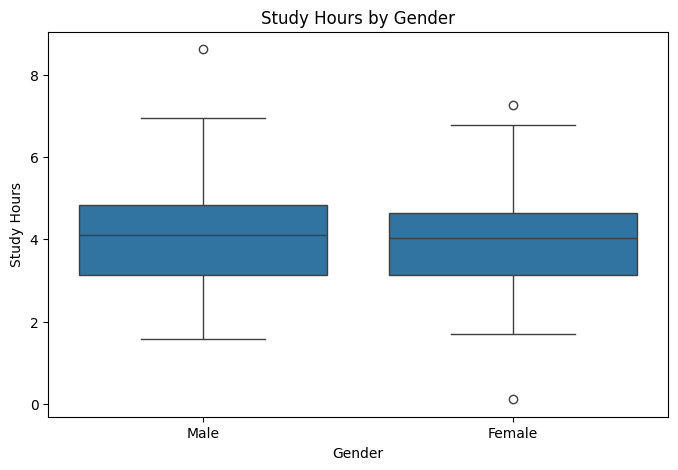

In [24]:
# Run test, print result, verdict, boxplot

# Separate groups
male_hours = df[df['gender'] == 'Male']['study_hours']
female_hours = df[df['gender'] == 'Female']['study_hours']

# Mann-Whitney U Test
u_stat, p_value = stats.mannwhitneyu(male_hours, female_hours, alternative='two-sided')

# u_stat: a number that tells how much the two groups differ in their values, based on ranking all observations;
# bigger differences in ranks between groups → higher or lower U statistic

print("U Statistic:", u_stat)
print("P-value:", p_value)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='gender', y='study_hours')
plt.title('Study Hours by Gender')
plt.xlabel('Gender')
plt.ylabel('Study Hours')
plt.show()

# verdict
# P-value = 0.6156 (which is much greater than 0.05)
# There is no significant difference in study hours between male and female students.
# In other words, both groups study about the same amount of time.

# Why Mann-Whitney and not t-test?
# Answer: because study hours are likely not normally distributed (skewed).
# Unlike the t-test, it does not assume normality and is better for comparing medians between two groups.

---
## Task 6 — Pearson + Spearman: Study Hours vs Marks

Run **both** Pearson and Spearman on (study_hours, marks).

- Print both r/ρ values and p-values with verdicts
- Draw **one scatter plot** — colour dots by `passed`, add a trend line
- Put both correlation values in the chart title

💡 `stats.pearsonr` · `stats.spearmanr` · `sns.scatterplot(hue=)` · `np.polyfit`

Pearson r: 0.630482176063945
Pearson p-value: 1.4633486625891946e-23
Spearman rho: 0.5866076651916298
Spearman p-value: 7.031216399376377e-20
Pearson: Significant relationship
Spearman: Significant relationship


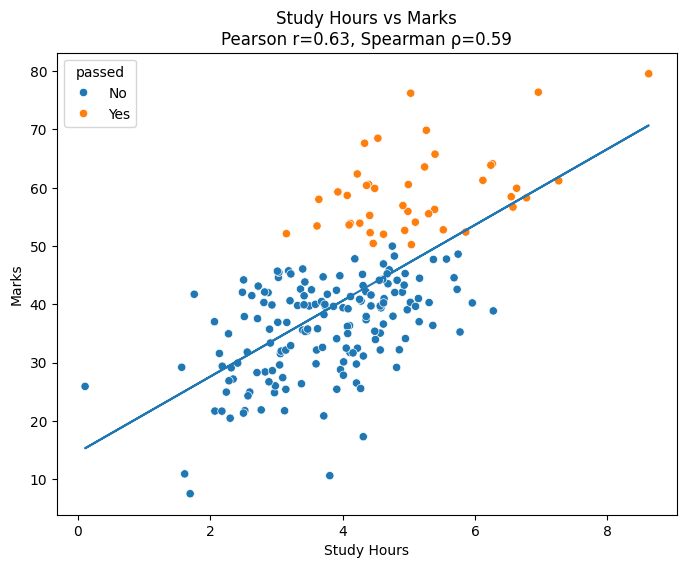

In [25]:
# Both tests + scatter with trend line
# Pearson Correlation
pearson_r, pearson_p = stats.pearsonr(df['study_hours'], df['marks'])

# Spearman Correlation
spearman_rho, spearman_p = stats.spearmanr(df['study_hours'], df['marks'])

print("Pearson r:", pearson_r)
print("Pearson p-value:", pearson_p)

print("Spearman rho:", spearman_rho)
print("Spearman p-value:", spearman_p)

# Pearson verdict
if pearson_p < 0.05:
    print("Pearson: Significant relationship")
else:
    print("Pearson: No significant relationship")

# Spearman verdict
if spearman_p < 0.05:
    print("Spearman: Significant relationship")
else:
    print("Spearman: No significant relationship")

plt.figure(figsize=(8,6))

# Scatter plot
sns.scatterplot(data=df, x='study_hours', y='marks', hue='passed')

# Trend line (linear fit)
x = df['study_hours']
y = df['marks']
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

# Title with correlation values
plt.title(f"Study Hours vs Marks\nPearson r={pearson_r:.2f}, Spearman ρ={spearman_rho:.2f}")

plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.show()


# Pearson r: shows how strongly two numbers move together in a straight line, range is -1 to 1
# Pearson p: tells if that straight-line relationship is real or just by chance
# Spearman rho (ρ): shows how strongly two numbers move together in order (rank), even if not straight line, range is -1 to 1
# Spearman p: tells if that rank-based relationship is real or just by chance




# Do Pearson and Spearman agree? What does that tell you?
# Answer: Smaller p-values increase statistical significance, 
# while a smaller difference between Pearson (r) and Spearman (ρ) indicates a more consistent (likely linear) relationship.
# Yes, they agree — both show a positive relationship, which means study hours and marks increase together in a fairly linear way.


---
## Task 7 — Correlation Heatmap with Significance Mask

1. Compute the full correlation matrix for the 3 numeric columns
2. Build a p-value matrix using a nested loop (Pearson for each pair)
3. Create a **mask** where p > 0.05
4. Draw **two heatmaps side by side** — full matrix vs masked (significant only)

💡 `df.corr()` · nested loop with `stats.pearsonr` · `sns.heatmap(mask=)`

                marks  study_hours  sleep_hours
marks        1.000000     0.630482     0.065181
study_hours  0.630482     1.000000    -0.015980
sleep_hours  0.065181    -0.015980     1.000000
                    marks   study_hours  sleep_hours
marks        0.000000e+00  1.463349e-23     0.359144
study_hours  1.463349e-23  0.000000e+00     0.822304
sleep_hours  3.591439e-01  8.223042e-01     0.000000


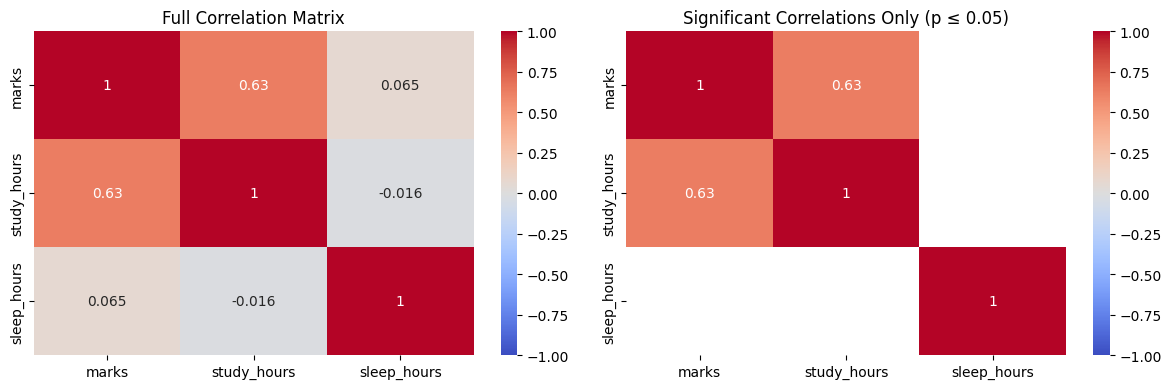

In [26]:
num_cols = ['marks', 'study_hours', 'sleep_hours']

# Correlation matrix
corr_matrix = df[num_cols].corr()  # Pearson correlations
print(corr_matrix)

# p-value matrix (nested loop)
p_matrix = pd.DataFrame(np.ones((len(num_cols), len(num_cols))), columns=num_cols, index=num_cols)

# Nested loop for Pearson p-values
for i in num_cols:
    for j in num_cols:
        if i == j:
            p_matrix.loc[i,j] = 0  # p-value of a variable with itself is 0
        else:
            _, p = stats.pearsonr(df[i], df[j])
            p_matrix.loc[i,j] = p

print(p_matrix)



# Mask
mask = p_matrix > 0.05  # True for p > 0.05

# Two heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Full correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Full Correlation Matrix')

# Masked heatmap (significant correlations only)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, mask=mask, ax=axes[1])
axes[1].set_title('Significant Correlations Only (p ≤ 0.05)')



plt.tight_layout()
plt.show()

---
## Task 8 — Chi-Square: Subject vs Passed

**Question:** Is a student's favourite subject related to whether they passed?

- Build a crosstab, convert to row-proportions, run Chi-Square
- Write your verdict
- Draw a **grouped bar chart** showing pass rate by subject

💡 `pd.crosstab` · `.div(axis=0)` · `stats.chi2_contingency` · `DataFrame.plot(kind='bar')`

passed   No  Yes
subject         
Arts     38    9
Maths    63   22
Science  57   11
passed         No       Yes
subject                    
Arts     0.808511  0.191489
Maths    0.741176  0.258824
Science  0.838235  0.161765
Chi-square statistic: 2.2720534483656105
P-value: 0.3210922788271437
Verdict: Subject is NOT related to passing (not significant).


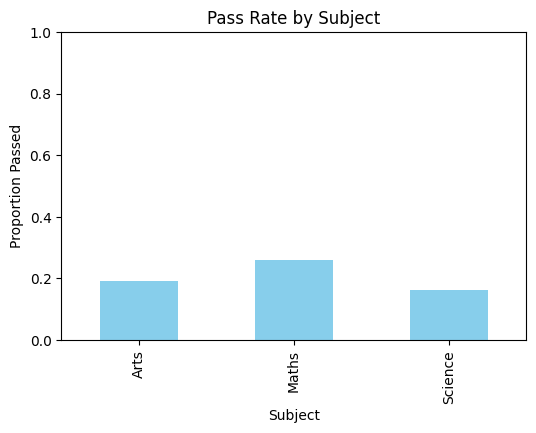

In [27]:
# Crosstab, proportion table, chi-square, verdict, grouped bar chart
ct = pd.crosstab(df['subject'], df['passed'])
print(ct)

# Row-wise proportions
ct_prop = ct.div(ct.sum(axis=1), axis=0)
print(ct_prop)

chi2, p, dof, expected = stats.chi2_contingency(ct)

print("Chi-square statistic:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Verdict: Subject is related to passing (significant).")
else:
    print("Verdict: Subject is NOT related to passing (not significant).")

# Bar chart of pass rate by subject
ct_prop['Yes'].plot(kind='bar', color='skyblue', figsize=(6,4))
plt.title('Pass Rate by Subject')
plt.ylabel('Proportion Passed')
plt.xlabel('Subject')
plt.ylim(0,1)
plt.show()






# Which subject has the highest pass rate?
# Answer: Maths(25.88%)

---
## Task 9 — 🎓 The Cheating Story

A student scored **85**. The class uses your `df` marks. The teacher is suspicious.

**Part A:** Run a one-sample t-test. Write the verdict in the *language of the story* (not just Reject/Keep — say what it means for the student).

**Part B — Sensitivity:** Loop scores 55 to 100. For each, compute the p-value. Plot **score vs p-value** with the α line. Mark the threshold where suspicion begins.

💡 `stats.ttest_1samp(data, popmean=)` · `np.arange` · `ax.axhline` · `ax.axvline`

T-statistic: -50.18527446494796
P-value: 6.358272134156497e-115


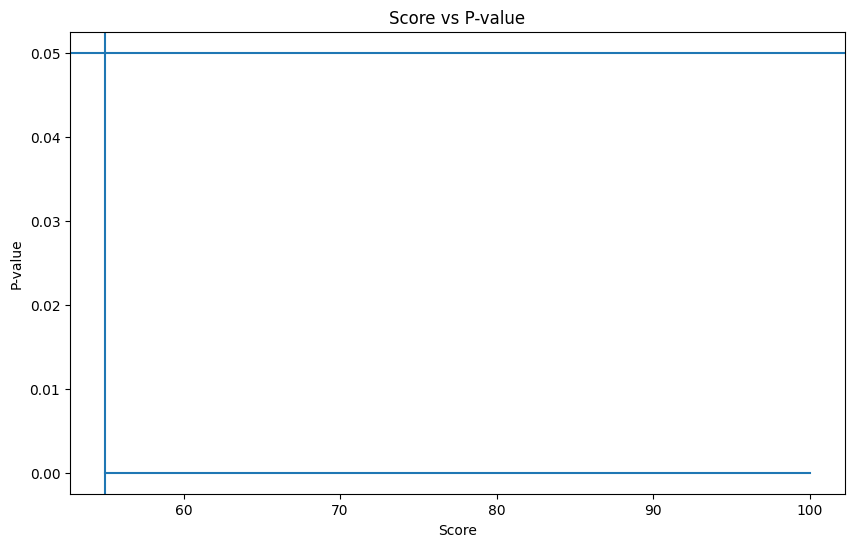

Threshold score: 55


In [28]:
# Part A
data = df['marks']
student_score = 85

t_stat, p_value = stats.ttest_1samp(data, popmean=student_score)

print("T-statistic:", t_stat)
print("P-value:", p_value)






# Part B — loop + sensitivity plot

scores = np.arange(55, 101)
p_values = []

for s in scores:
    _, p = stats.ttest_1samp(data, popmean=s)
    p_values.append(p)

p_values = np.array(p_values)

alpha = 0.05

# find first score where p < 0.05
threshold_index = np.where(p_values < alpha)[0][0]
# where() contains a tuple, [0] means return the array at index 0 of that tuple(that has all indices where p_values<alpha is true)
# second [0] means return the first value of that array(the first value is an index as this array contaons all indices where the condition is true)
threshold_score = scores[threshold_index]

# plot
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(scores, p_values)

ax.axhline(y=alpha)          # significance line
ax.axvline(x=threshold_score)  # threshold line

ax.set_title("Score vs P-value")
ax.set_xlabel("Score")
ax.set_ylabel("P-value")

plt.show()

print("Threshold score:", threshold_score)





# At what score does the test become significant?
# Answer: at 55(threshhold score)
# The teacher looks at the class marks and realizes that a score of 85 is almost impossible to happen naturally.
# The chances are nearly zero. This makes the teacher very suspicious that something unusual (like cheating) may have happened


# What is the vertical line?
# 👉 The vertical line is drawn at score = 55
# It marks the first point where the result becomes suspicious
# (i.e., where p-value goes below 0.05)
# In this graph, it starts immediately at 55 — meaning everything from 55 to 100 looks suspicious.”



# The horizontal line (at 0.05)
# 👉 This is the cutoff line
# Above the line → ✅ normal score
# Below the line → 🚨 suspicious score

# The curve (your p-values)
# 👉 This tells how unusual each score is, it has all the p values of scores from 55 to 100
# Because all those p-values are:
# very very small (close to 0)
# So visually it looks like a flat line at the bottom.


# “If the line is below 0.05 → suspicious.
# In this graph, everything is below → everything looks suspicious.”

---
## Task 10 — Parametric vs Non-Parametric on Skewed Data

Create a **skewed version** of marks: `np.where(marks > 80, marks**1.4, marks)`, clip to 100.

Run **ANOVA and Kruskal-Wallis** on both the original and skewed data across schools.

Show all 4 results in a **2×2 subplot** (original vs skewed × ANOVA vs Kruskal).

Then answer: which test is more reliable on skewed data, and why?

💡 `stats.f_oneway` · `stats.kruskal` · `sns.boxplot` in each subplot

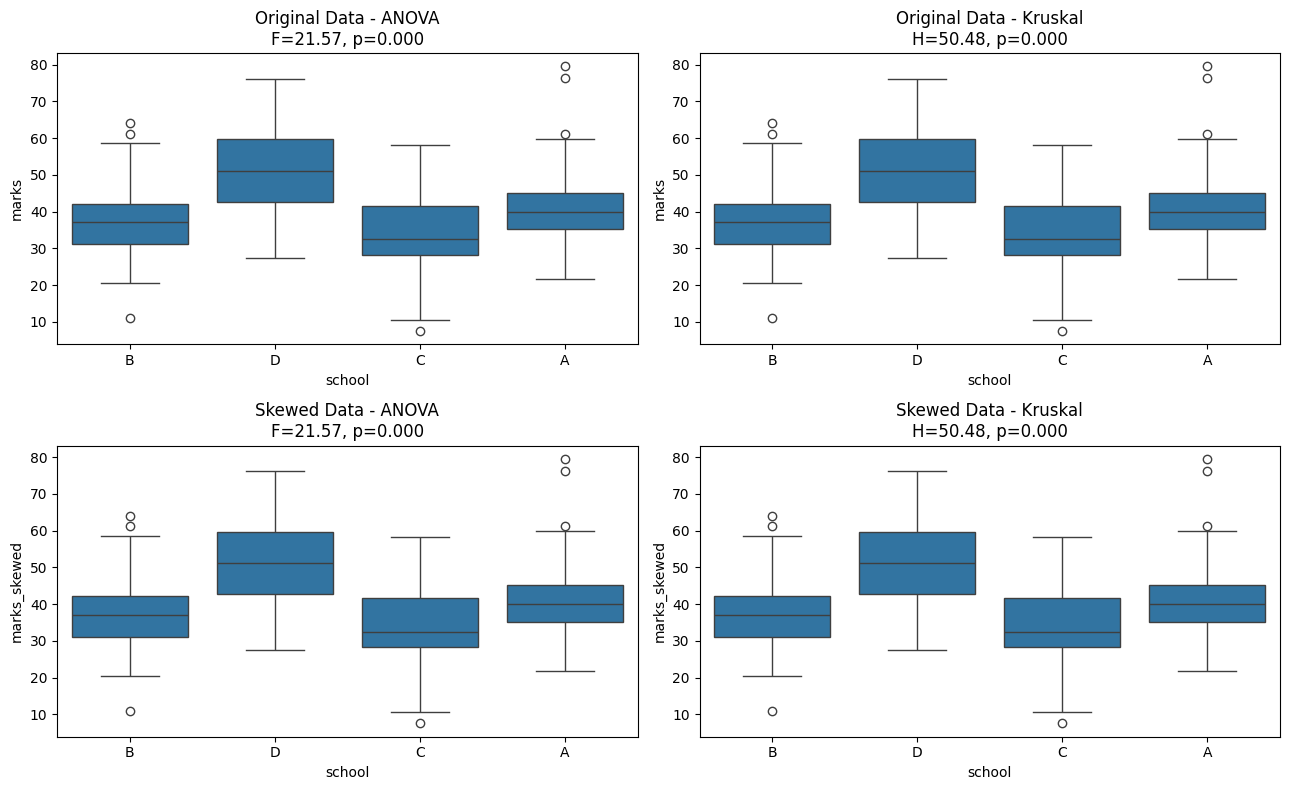

In [29]:
# Skewed version
marks_skewed = np.clip(np.where(df['marks'] > 80, df['marks'] ** 1.4, df['marks']), 0, 100) 
# to create skewness, imbalance
# Ensures values stay between 0 and 100
# If any value goes above 100 → it is set to 100
df['marks_skewed'] = marks_skewed

schools = df['school'].unique()
groups_orig = [df['marks'][df['school']==s] for s in schools]
groups_skew = [df['marks_skewed'][df['school']==s] for s in schools]

# Run all 4 tests and store p-values
anova_orig = stats.f_oneway(*groups_orig)
anova_skew = stats.f_oneway(*groups_skew)

kruskal_orig = stats.kruskal(*groups_orig)
kruskal_skew = stats.kruskal(*groups_skew)

# store p-values for reference
p_values = {
    "ANOVA_Original": anova_orig.pvalue,
    "ANOVA_Skewed": anova_skew.pvalue,
    "Kruskal_Original": kruskal_orig.pvalue,
    "Kruskal_Skewed": kruskal_skew.pvalue
}




# 2×2 subplot
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
# Original data - ANOVA
sns.boxplot(x='school', y='marks', data=df, ax=axes[0,0])
axes[0,0].set_title(f"Original Data - ANOVA\nF={anova_orig.statistic:.2f}, p={anova_orig.pvalue:.3f}")

# Original data - Kruskal
sns.boxplot(x='school', y='marks', data=df, ax=axes[0,1])
axes[0,1].set_title(f"Original Data - Kruskal\nH={kruskal_orig.statistic:.2f}, p={kruskal_orig.pvalue:.3f}")

# Skewed data - ANOVA
sns.boxplot(x='school', y='marks_skewed', data=df, ax=axes[1,0])
axes[1,0].set_title(f"Skewed Data - ANOVA\nF={anova_skew.statistic:.2f}, p={anova_skew.pvalue:.3f}")

# Skewed data - Kruskal
sns.boxplot(x='school', y='marks_skewed', data=df, ax=axes[1,1])
axes[1,1].set_title(f"Skewed Data - Kruskal\nH={kruskal_skew.statistic:.2f}, p={kruskal_skew.pvalue:.3f}")





plt.tight_layout()
plt.show()

# Which test is more reliable on skewed data?
# Answer: Kruskal-Wallis is more reliable on skewed data because it does not assume normal distribution.

---
## Task 11 — Your Own Question

Pick **any relationship** in the dataset that hasn't been tested yet.  
Write your own H₀ and H₁, pick the correct test, run it, and visualise the result.

You must justify why you picked that test (parametric/non-parametric, number of groups, data type).

T-statistic: -0.2400856216680583
P-value: 0.810512259540317


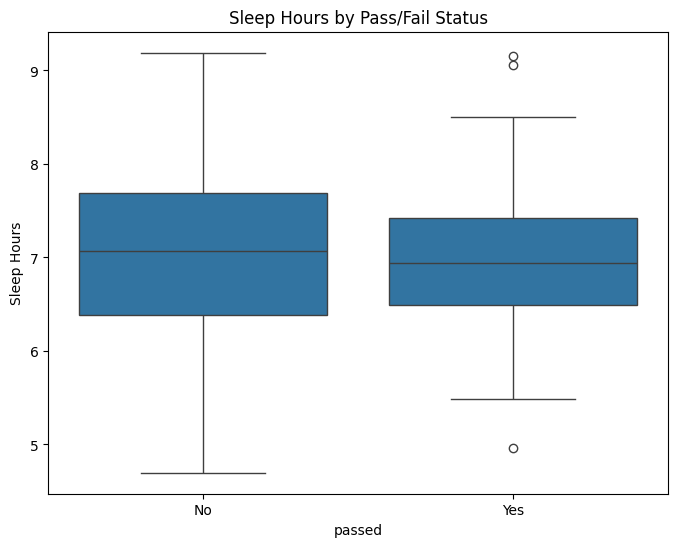

Verdict: Fail to reject H₀: Sleep hours are similar for passed and failed students.


In [30]:
# H₀: Students who passed and students who failed have the same average sleep hours
# H₁: Students who passed and students who failed have different average sleep hours
# Test chosen: t-test
# Justification: 
# - sleep_hours is continuous and approximately normal (Shapiro-Wilk p = 0.5952)
# - Two independent groups (passed vs failed)

# Your code:
sleep_pass = df['sleep_hours'][df['passed'] == 'Yes']
sleep_fail = df['sleep_hours'][df['passed'] == 'No']

# Independent t-test
t_stat, p_value = stats.ttest_ind(sleep_pass, sleep_fail)
print("T-statistic:", t_stat)
print("P-value:", p_value)

# Visualise
plt.figure(figsize=(8,6))
sns.boxplot(x='passed', y='sleep_hours', data=df)
plt.title("Sleep Hours by Pass/Fail Status")
plt.ylabel("Sleep Hours")
plt.show()




# Verdict: 
if p_value < 0.05:
    verdict = "Reject H₀: Students who passed and failed have significantly different sleep hours."
else:
    verdict = "Fail to reject H₀: Sleep hours are similar for passed and failed students."

print("Verdict:", verdict)

---
## Task 12 — Summary Dashboard

Collect all your p-values from Tasks 2–10 into a list of dicts.  
Convert to a DataFrame and print the table.  
Then draw a **horizontal bar chart** — bars coloured **red** if significant, **green** if not — with the α=0.05 line.

💡 `pd.DataFrame(list_of_dicts)` · `ax.barh()` · `ax.axvline(0.05)`

                             Test        p_value  Significant  \
0            Shapiro-Wilk — marks   8.400000e-03         True   
1      Shapiro-Wilk — study_hours   1.014000e-01        False   
2        t-test — gender vs marks   9.343000e-01        False   
3         ANOVA — school vs marks   0.000000e+00         True   
4  Mann-Whitney — gender vs study   6.155000e-01        False   
5        Pearson — study vs marks   1.463000e-23         True   
6       Spearman — study vs marks   7.031000e-20         True   
7  Chi-Square — subject vs passed   3.210000e-01        False   
8         One-sample t — cheating  6.350000e-115         True   

             Verdict  
0          Reject H₀  
1  Fail to reject H₀  
2  Fail to reject H₀  
3          Reject H₀  
4  Fail to reject H₀  
5          Reject H₀  
6          Reject H₀  
7  Fail to reject H₀  
8          Reject H₀  


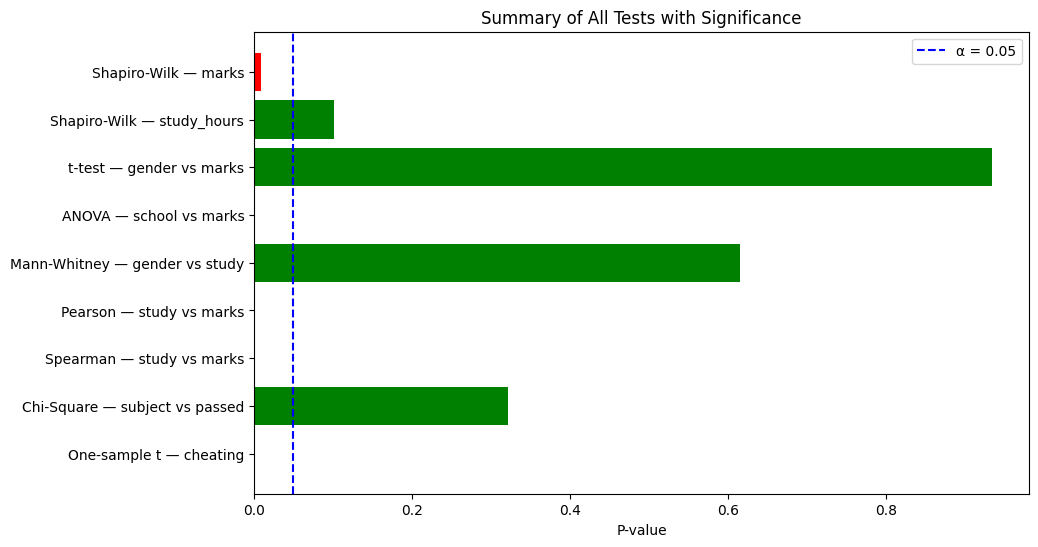

In [31]:
# Build results list — fill in your p-values from earlier tasks
results = [
    {'Test': 'Shapiro-Wilk — marks',          'p_value': 0.0084},
    {'Test': 'Shapiro-Wilk — study_hours',     'p_value': 0.1014},
    {'Test': 't-test — gender vs marks',       'p_value': 0.93430},
    {'Test': 'ANOVA — school vs marks',        'p_value': 0.0000},
    {'Test': 'Mann-Whitney — gender vs study', 'p_value': 0.6155},
    {'Test': 'Pearson — study vs marks',       'p_value': 1.463e-23},
    {'Test': 'Spearman — study vs marks',      'p_value': 7.031e-20},
    {'Test': 'Chi-Square — subject vs passed', 'p_value': 0.3210},
    {'Test': 'One-sample t — cheating',        'p_value': 6.35e-115},
]

df_results = pd.DataFrame(results)

alpha = 0.05
df_results['Significant'] = df_results['p_value'] < alpha
df_results['Verdict'] = df_results['Significant'].apply(
    lambda x: "Reject H₀" if x else "Fail to reject H₀"
)

print(df_results)

# Add 'significant' and 'verdict' columns, print table, draw bar chart
plt.figure(figsize=(10,6))
colors = ['red' if sig else 'green' for sig in df_results['Significant']]

plt.barh(df_results['Test'], df_results['p_value'], color=colors)
plt.axvline(x=alpha, color='blue', linestyle='--', label='α = 0.05')
plt.xlabel("P-value")
plt.title("Summary of All Tests with Significance")
plt.legend()
plt.gca().invert_yaxis()  # largest bar on top
plt.show()






---
## ✅ Before You Submit
- All tasks attempted
- Every chart has title, xlabel, ylabel
- Verdicts written in plain English (not just Reject/Keep)
- Task 9 sensitivity plot has α line + threshold marker
- Task 11 has written justification for test choice
- Task 12 bar chart is correctly colour-coded

---
*Statistics doesn't prove truth — it measures surprise. 🎓*